# 🏦 Bank Personal Loan Granting — Machine Learning Analysis

**Course:** BDA401 — Machine Learning Project  
**Dataset:** Bank_Loan_Granting.csv (5,000 bank customers)  
**Objective:** Binary classification — predict whether a customer will be granted a personal loan

---

## 1. Problem Statement

### What is predicted?
Whether a bank customer will be **granted** a personal loan (`Personal Loan = 1`) or **denied** (`Personal Loan = 0`), given their demographic and financial profile.

### Why is it important?
Manual loan assessment is slow, inconsistent, and prone to human bias. An accurate ML model can:
- **Reduce processing time** from days to seconds
- **Improve consistency** — identical profiles receive identical decisions
- **Lower default risk** — by better identifying creditworthy customers

### Who benefits?

| Stakeholder | Benefit |
|-------------|---------|
| **Bank** | Higher loan conversion rate, lower default risk |
| **Loan Officers** | Automated pre-screening reduces workload |
| **Customers** | Faster, fairer, more transparent decisions |
| **Risk Dept.** | Data-driven portfolio management |

---

## 2. Dataset Description

| Property | Value |
|----------|-------|
| **Source** | Simulated bank marketing dataset |
| **Total records** | 5,000 customers |
| **Raw columns** | 14 |
| **Features used** | 11 (after dropping `ID` and `ZIP Code`) |
| **Target variable** | `Personal Loan` — binary |
| **Class distribution** | ~90.4 % Not Granted · ~9.6 % Granted |
| **Missing values** | None (after `CCAvg` fix) |
| **Notable quirk** | `CCAvg` stored with `"/"` as decimal separator |

> ⚠️ **Class imbalance:** The ~10:1 ratio means raw accuracy is misleading. We prioritise **F1-score** (and Precision/Recall) throughout.

### Feature Descriptions

| Feature | Description |
|---------|-------------|
| `Age` | Customer age (years) |
| `Experience` | Years of professional experience |
| `Income` | Annual income ($ thousands) |
| `Family` | Family size (1–4) |
| `CCAvg` | Average monthly credit-card spend ($ thousands) |
| `Education` | 1 = Undergrad, 2 = Graduate, 3 = Advanced/Professional |
| `Mortgage` | Value of home mortgage, if any ($ thousands) |
| `Securities Account` | Does the customer hold a securities account? (0/1) |
| `CD Account` | Does the customer hold a CD account? (0/1) |
| `Online` | Does the customer use internet banking? (0/1) |
| `CreditCard` | Does the customer use a bank-issued credit card? (0/1) |
| **`Personal Loan`** | **TARGET — Was the loan granted? (0 = Not Granted, 1 = Granted)** |

---
## Section 2 — Setup: Import Required Libraries

We import all necessary libraries up front:
- **pandas / numpy** — data manipulation  
- **matplotlib / seaborn** — visualisation  
- **scikit-learn** — preprocessing, modelling, evaluation, and pipelines  
- **ipywidgets** — interactive in-notebook UI  
- **joblib** — saving / loading trained models

In [19]:
# ── Standard library ──────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

# ── Data handling ─────────────────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Visualisation ─────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import ListedColormap
import seaborn as sns

plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False,
                     "axes.spines.right": False})
sns.set_theme(style="whitegrid", palette="muted")

# ── Scikit-learn ──────────────────────────────────────────────────────────────
from sklearn.model_selection     import (train_test_split, cross_val_score,
                                          StratifiedKFold, GridSearchCV)
from sklearn.preprocessing       import StandardScaler, LabelEncoder
from sklearn.pipeline            import Pipeline
from sklearn.ensemble            import RandomForestClassifier
from sklearn.linear_model        import LogisticRegression
from sklearn.tree                import DecisionTreeClassifier, plot_tree
from sklearn.neighbors           import KNeighborsClassifier
from sklearn.decomposition       import PCA
from sklearn.metrics             import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    accuracy_score, f1_score,
    precision_score, recall_score
)
from sklearn.inspection          import permutation_importance

# ── Model persistence ─────────────────────────────────────────────────────────
import joblib

# ── Interactive widgets ───────────────────────────────────────────────────────
import ipywidgets as widgets
from IPython.display import display, HTML, clear_output

print("✅  All libraries imported successfully.")

✅  All libraries imported successfully.


---
## Section 3 — Data Exploration

Key things to check on first load:
1. Shape (rows × columns)  
2. Data types — are any columns read incorrectly?  
3. Missing values  
4. Basic statistics (mean, std, quantiles)
5. Target class distribution (check for imbalance)

In [20]:
# ── Load raw CSV ──────────────────────────────────────────────────────────────
df_raw = pd.read_csv("Bank_Loan_Granting.csv")
print(f"Shape: {df_raw.shape}")
df_raw.head(10)

Shape: (5000, 14)


,ID,Age,Experience,Income,ZIP Code,Family,CCAvg,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
0,1,25,1,49,91107,4,1/60,1,0,0,1,0,0,0
1,2,45,19,34,90089,3,1/50,1,0,0,1,0,0,0
2,3,39,15,11,94720,1,1/00,1,0,0,0,0,0,0
3,4,35,9,100,94112,1,2/70,2,0,0,0,0,0,0
4,5,35,8,45,91330,4,1/00,2,0,0,0,0,0,1
5,6,37,13,29,92121,4,0/40,2,155,0,0,0,1,0
6,7,53,27,72,91711,2,1/50,2,0,0,0,0,1,0
7,8,50,24,22,93943,1,0/30,3,0,0,0,0,0,1
8,9,35,10,81,90089,3,0/60,2,104,0,0,0,1,0
9,10,34,9,180,93023,1,8/90,3,0,1,0,0,0,0


In [21]:
# ── Data types, nulls, stats ──────────────────────────────────────────────────
print("=== Data Types ===")
print(df_raw.dtypes)
print("\n=== Missing Values ===")
print(df_raw.isnull().sum())
print("\n=== Basic Statistics ===")
df_raw.describe()

=== Data Types ===
ID                     int64
Age                    int64
Experience             int64
Income                 int64
ZIP Code               int64
Family                 int64
CCAvg                 object
Education              int64
Mortgage               int64
Personal Loan          int64
Securities Account     int64
CD Account             int64
Online                 int64
CreditCard             int64
dtype: object

=== Missing Values ===
ID                    0
Age                   0
Experience            0
Income                0
ZIP Code              0
Family                0
CCAvg                 0
Education             0
Mortgage              0
Personal Loan         0
Securities Account    0
CD Account            0
Online                0
CreditCard            0
dtype: int64

=== Basic Statistics ===


,ID,Age,Experience,Income,ZIP Code,Family,Education,Mortgage,Personal Loan,Securities Account,CD Account,Online,CreditCard
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.00000,5000.000000,5000.000000
mean,2500.500000,45.338400,20.104600,73.774200,93152.503000,2.396400,1.881000,56.498800,0.096000,0.104400,0.06040,0.596800,0.294000
std,1443.520003,11.463166,11.467954,46.033729,2121.852197,1.147663,0.839869,101.713802,0.294621,0.305809,0.23825,0.490589,0.455637
min,1.000000,23.000000,-3.000000,8.000000,9307.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
25%,1250.750000,35.000000,10.000000,39.000000,91911.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
50%,2500.500000,45.000000,20.000000,64.000000,93437.000000,2.000000,2.000000,0.000000,0.000000,0.000000,0.00000,1.000000,0.000000
75%,3750.250000,55.000000,30.000000,98.000000,94608.000000,3.000000,3.000000,101.000000,0.000000,0.000000,0.00000,1.000000,1.000000
max,5000.000000,67.000000,43.000000,224.000000,96651.000000,4.000000,3.000000,635.000000,1.000000,1.000000,1.00000,1.000000,1.000000


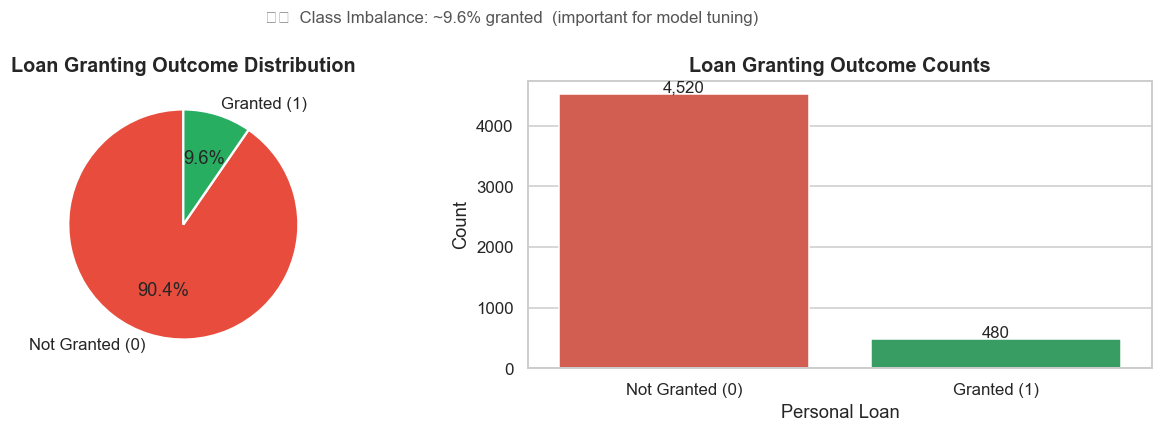

In [22]:
# ── Target class distribution ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie chart
counts = df_raw["Personal Loan"].value_counts()
axes[0].pie(counts, labels=["Not Granted (0)", "Granted (1)"],
            colors=["#e74c3c", "#27ae60"], autopct="%1.1f%%",
            startangle=90, wedgeprops={"edgecolor": "white", "linewidth": 1.5})
axes[0].set_title("Loan Granting Outcome Distribution", fontsize=13, fontweight="bold")

# Count bar
sns.countplot(x="Personal Loan", data=df_raw, palette=["#e74c3c", "#27ae60"], ax=axes[1])
axes[1].set_xticklabels(["Not Granted (0)", "Granted (1)"])
axes[1].set_title("Loan Granting Outcome Counts", fontsize=13, fontweight="bold")
axes[1].set_xlabel("Personal Loan")
axes[1].set_ylabel("Count")
for bar in axes[1].patches:
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 30,
                 f"{int(bar.get_height()):,}", ha="center", fontsize=11)

plt.suptitle("⚠️  Class Imbalance: ~9.6% granted  (important for model tuning)",
             fontsize=11, color="#555")
plt.tight_layout()
plt.show()

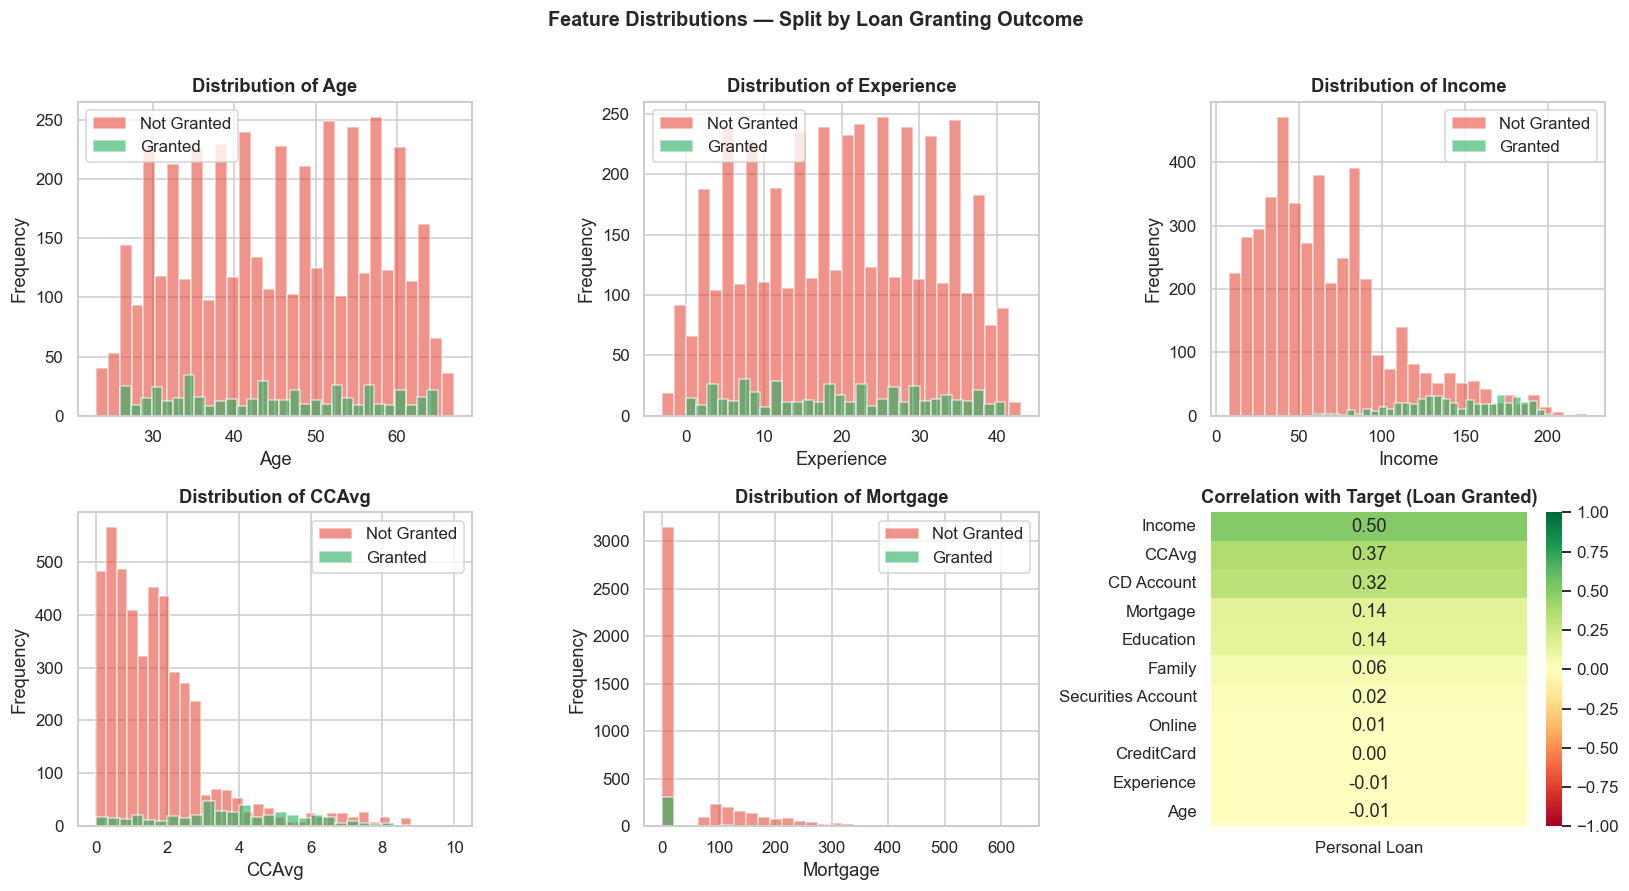

In [23]:
# ── Continuous feature distributions by loan granting status ──────────────────
cont_features = ["Age", "Experience", "Income", "CCAvg", "Mortgage"]

# Fix CCAvg first for raw df visualisation
df_vis = df_raw.copy()
df_vis["CCAvg"] = df_vis["CCAvg"].astype(str).str.replace("/", ".", regex=False).astype(float)

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(cont_features):
    not_granted = df_vis.loc[df_vis["Personal Loan"] == 0, feat]
    granted     = df_vis.loc[df_vis["Personal Loan"] == 1, feat]
    axes[i].hist(not_granted, bins=30, alpha=0.6, color="#e74c3c", label="Not Granted")
    axes[i].hist(granted,     bins=30, alpha=0.6, color="#27ae60", label="Granted")
    axes[i].set_title(f"Distribution of {feat}", fontweight="bold")
    axes[i].set_xlabel(feat)
    axes[i].set_ylabel("Frequency")
    axes[i].legend()

# Correlation heatmap in last subplot
numeric_cols = ["Age", "Experience", "Income", "Family", "CCAvg",
                "Education", "Mortgage", "Securities Account",
                "CD Account", "Online", "CreditCard", "Personal Loan"]
corr = df_vis[numeric_cols].corr()
sns.heatmap(corr[["Personal Loan"]].sort_values("Personal Loan", ascending=False).drop("Personal Loan"),
            annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            vmin=-1, vmax=1, ax=axes[5], cbar=True)
axes[5].set_title("Correlation with Target (Loan Granted)", fontweight="bold")

plt.suptitle("Feature Distributions — Split by Loan Granting Outcome", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

---
## Section 4 — Hypothesis

Based on the data exploration above, we state our hypotheses before modelling.

| Factor | Hypothesis | Evidence from EDA |
|--------|-----------|-------------------|
| **Linearity** | **Non-linear** boundary | Income × CCAvg scatter shows curved cluster separation, not a straight line |
| **Separability** | **Partial** | Granted customers cluster at high Income + high CCAvg, but overlap exists at mid-range |
| **Noise level** | **Low-moderate** | Clean bank records; borderline customers introduce ambiguity |
| **Key drivers** | `Income`, `CCAvg`, `CD Account` | Highest correlation with target in heatmap |

### Predicted model ranking (before training)

| Rank | Model | Reasoning |
|------|-------|-----------|
| 1 | **Random Forest** | Best handles non-linearity, interactions, and class imbalance robustly |
| 2 | **Decision Tree** | Interpretable splits, but expected to overfit on training data |
| 3 | **KNN** | Captures local patterns; sensitive to scale and the sparse minority class |
| 4 | **Logistic Regression** | Useful linear baseline; likely limited by the non-linear boundary |

> We expect **non-linear ensemble methods** to outperform the linear model significantly, given the curved decision boundary visible in the Income × CCAvg space.

---
## Section 5 — Data Preprocessing & Feature Engineering

Steps performed:
1. **Fix `CCAvg`** — values stored as `"1/60"` (slash as decimal separator); we replace `"/"` with `"."` and cast to float.
2. **Drop irrelevant columns** — `ID` (identifier, no signal) and `ZIP Code` (high-cardinality postal code with no engineered encoding).
3. **Check for negative `Experience`** — some rows may have negative experience (data entry error); we clip to 0.
4. **Scale features** — `StandardScaler` (mean=0, std=1) for models sensitive to scale (Logistic Regression, KNN).  Random Forest and Decision Tree are scale-invariant.

In [24]:
FEATURE_COLS = [
    "Age", "Experience", "Income", "Family", "CCAvg",
    "Education", "Mortgage", "Securities Account", "CD Account", "Online", "CreditCard"
]
TARGET_COL = "Personal Loan"

# ── Preprocessing pipeline ────────────────────────────────────────────────────
df = df_raw.copy()

# Fix CCAvg encoding
df["CCAvg"] = df["CCAvg"].astype(str).str.replace("/", ".", regex=False).astype(float)

# Drop non-predictive columns
df.drop(columns=["ID", "ZIP Code"], inplace=True)

# Clip negative experience values (data artefact)
df["Experience"] = df["Experience"].clip(lower=0)

# Verify no missing values remain
assert df.isnull().sum().sum() == 0, "Unexpected missing values!"

print("✅  Preprocessing complete")
print(f"   Dataset shape : {df.shape}")
print(f"   Feature range :\n{df[FEATURE_COLS].agg(['min','max']).T}")

X = df[FEATURE_COLS]
y = df[TARGET_COL]

✅  Preprocessing complete
   Dataset shape : (5000, 12)
   Feature range :
                     min    max
Age                 23.0   67.0
Experience           0.0   43.0
Income               8.0  224.0
Family               1.0    4.0
CCAvg                0.0   10.0
Education            1.0    3.0
Mortgage             0.0  635.0
Securities Account   0.0    1.0
CD Account           0.0    1.0
Online               0.0    1.0
CreditCard           0.0    1.0


---
## Section 6 — Experimental Design

### 6a. Train-Test Split

We use an **80/20 stratified split** with `stratify=y` to preserve the class ratio in both sets.

$$P(\text{Granted in test set}) \approx P(\text{Granted in train set}) \approx 9.6\%$$

This prevents the model from being evaluated on a test set with very different class proportions.

### 6b. Cross-Validation Strategy

- **5-fold Stratified K-Fold** on the full dataset
- Primary metric: **F1-Score** (balances Precision and Recall; appropriate for imbalanced classes)
- Secondary metrics: Accuracy, Precision, Recall

### 6c. Algorithms Evaluated (Four Total)

| # | Algorithm | Type | Scaling required |
|---|-----------|------|-----------------|
| 1 | **Logistic Regression** | Linear, probabilistic | ✅ Yes |
| 2 | **Decision Tree** | Rule-based, non-linear | ❌ No |
| 3 | **Random Forest** ✅ | Ensemble (bagging) | ❌ No |
| 4 | **K-Nearest Neighbours (KNN)** | Instance-based | ✅ Yes |

### 6d. Hyperparameter Tuning

`GridSearchCV` (3-fold inner CV) is applied to the **Random Forest** primary model to find the best combination of:

| Parameter | Values searched |
|-----------|----------------|
| `n_estimators` | 100, 200 |
| `max_depth` | None, 10, 20 |
| `min_samples_split` | 2, 5 |

In [25]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Scale features (needed for LR; RF uses unscaled)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"Training set : {X_train.shape[0]} samples  "
      f"({y_train.mean()*100:.1f}% granted)")
print(f"Test set     : {X_test.shape[0]} samples  "
      f"({y_test.mean()*100:.1f}% granted)")

Training set : 4000 samples  (9.6% granted)
Test set     : 1000 samples  (9.6% granted)


---
## Section 7 — Model Training

We train and compare **four supervised classifiers** as specified in the experimental design:

### 7a. Logistic Regression
A linear probabilistic model. The decision rule is based on the **logistic (sigmoid) function**:

$$\sigma(z) = \frac{1}{1 + e^{-z}}, \quad z = \beta_0 + \beta_1 x_1 + \cdots + \beta_n x_n$$

- If $\sigma(z) \geq 0.5$, predict **Granted**; otherwise **Not Granted**.  
- The boundary is a **hyperplane** in feature space.

### 7b. Decision Tree
Splits data hierarchically by the feature that reduces **Gini impurity** the most:

$$\text{Gini}(t) = 1 - \sum_{k=0}^{1} p_k^2$$

Each internal node tests a single feature; leaf nodes output a class label.

### 7c. Random Forest ✅ (Primary Model)
An **ensemble of decision trees** trained on bootstrap samples. Final prediction is the majority vote across all trees. Key advantages:
- Handles non-linear relationships naturally  
- Robust to outliers and collinear features  
- Provides feature importances via mean decrease in impurity  
- Much lower variance than a single Decision Tree

### 7d. K-Nearest Neighbours (KNN)
Classifies a new point by the majority label among its **k nearest neighbours** (Euclidean distance):

$$\hat{y} = \text{mode}\left(\{ y_i \mid i \in \text{kNN}(x) \}\right)$$

- Non-parametric — makes no assumption about the data distribution  
- Sensitive to feature scale → **requires StandardScaler**
- Computationally expensive at prediction time for large datasets

In [26]:
# ── 7.1  Train all four base models ──────────────────────────────────────────

lr  = LogisticRegression(max_iter=1000, random_state=42, C=1.0)
dt  = DecisionTreeClassifier(max_depth=6, random_state=42)
rf  = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
knn = KNeighborsClassifier(n_neighbors=5)

lr.fit(X_train_sc, y_train)   # needs scaled
dt.fit(X_train,    y_train)   # scale-invariant
rf.fit(X_train,    y_train)   # scale-invariant
knn.fit(X_train_sc, y_train)  # needs scaled

print("✅  All four base models trained.")

# ── 7.2  Hyperparameter tuning — Random Forest (GridSearchCV) ─────────────────
print("\n🔧  Running GridSearchCV on Random Forest (this may take ~30 s) …")

param_grid = {
    "n_estimators":      [100, 200],
    "max_depth":         [None, 10, 20],
    "min_samples_split": [2, 5],
}
cv_inner = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid,
    cv=cv_inner,
    scoring="f1",
    n_jobs=-1,
    verbose=0,
)
grid_search.fit(X_train, y_train)
rf_tuned = grid_search.best_estimator_

print(f"   Best parameters : {grid_search.best_params_}")
print(f"   Best CV F1-Score : {grid_search.best_score_:.4f}")

# ── 7.3  5-fold cross-validation comparison across all models ─────────────────
# Use Pipelines so scaling is applied inside each fold (prevents data leakage)
cv_outer = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_pipelines = {
    "Logistic Regression": Pipeline([("sc", StandardScaler()), ("clf", LogisticRegression(max_iter=1000, random_state=42))]),
    "Decision Tree":        DecisionTreeClassifier(max_depth=6, random_state=42),
    "Random Forest":        RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    "KNN (k=5)":            Pipeline([("sc", StandardScaler()), ("clf", KNeighborsClassifier(n_neighbors=5))]),
    "RF Tuned":             rf_tuned,
}

print("\n📊  5-fold Stratified CV — F1-Score:")
print(f"{'Model':<25} {'Mean':>8} {'Std':>8}  Fold scores")
print("-" * 75)

cv_summary = {}
for name, pipe in cv_pipelines.items():
    scores = cross_val_score(pipe, X, y, cv=cv_outer, scoring="f1", n_jobs=-1)
    cv_summary[name] = scores
    print(f"{name:<25} {scores.mean():>8.4f} {scores.std():>8.4f}  {np.round(scores, 4)}")

# Save the best model (tuned RF)
joblib.dump(rf_tuned,     "rf_model.pkl")
joblib.dump(scaler,       "scaler.pkl")
joblib.dump(FEATURE_COLS, "feature_cols.pkl")
print("\n✅  Tuned RF model saved to rf_model.pkl")

✅  All four base models trained.

🔧  Running GridSearchCV on Random Forest (this may take ~30 s) …
   Best parameters : {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
   Best CV F1-Score : 0.9134

📊  5-fold Stratified CV — F1-Score:
Model                         Mean      Std  Fold scores
---------------------------------------------------------------------------
Logistic Regression         0.7110   0.0135  [0.7251 0.7093 0.7219 0.7119 0.6867]
Decision Tree               0.9084   0.0183  [0.9149 0.9355 0.9101 0.9022 0.8791]
Random Forest               0.9297   0.0157  [0.9468 0.9451 0.9162 0.9333 0.9071]
KNN (k=5)                   0.7510   0.0409  [0.6962 0.7848 0.7875 0.7805 0.7059]
RF Tuned                    0.9320   0.0180  [0.9519 0.9508 0.9162 0.9341 0.9071]

✅  Tuned RF model saved to rf_model.pkl


,Fold 1,Fold 2,Fold 3,Fold 4,Fold 5,Mean F1,Std
RF Tuned,0.9519,0.9508,0.9162,0.9341,0.9071,0.9320,0.0201
Random Forest,0.9468,0.9451,0.9162,0.9333,0.9071,0.9297,0.0176
Decision Tree,0.9149,0.9355,0.9101,0.9022,0.8791,0.9084,0.0205
KNN (k=5),0.6962,0.7848,0.7875,0.7805,0.7059,0.7510,0.0458
Logistic Regression,0.7251,0.7093,0.7219,0.7119,0.6867,0.7110,0.0151


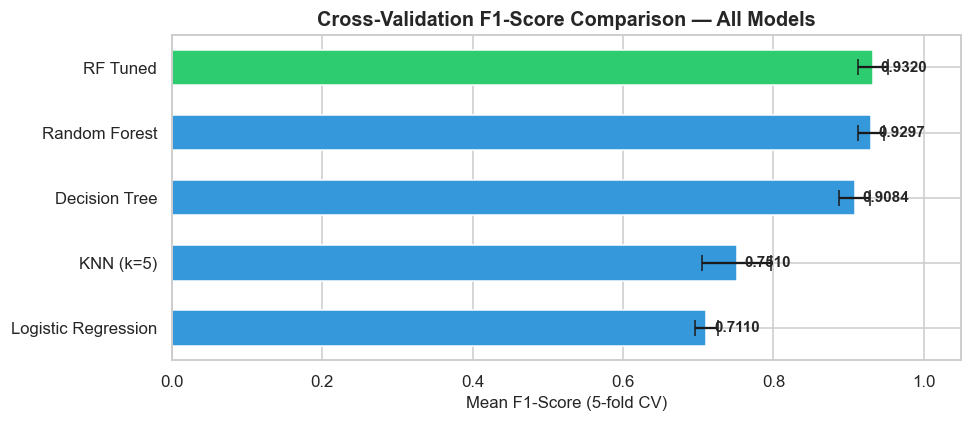

🟢 = Best model | Error bars = ±1 std across folds


In [27]:
# ── CV Comparison Table — all models ─────────────────────────────────────────
cv_table = pd.DataFrame(
    {name: scores for name, scores in cv_summary.items()},
    index=[f"Fold {i+1}" for i in range(5)]
).T
cv_table["Mean F1"] = cv_table.mean(axis=1)
cv_table["Std"]     = cv_table.iloc[:, :5].std(axis=1)
cv_table = cv_table.sort_values("Mean F1", ascending=False)

# ── Styled table ──────────────────────────────────────────────────────────────
display(
    cv_table.style
    .format("{:.4f}")
    .highlight_max(subset=["Mean F1"], color="#c8f7c5")
    .highlight_min(subset=["Mean F1"], color="#f7c8c8")
    .set_caption("📊  Cross-Validation F1-Score Comparison (5-Fold Stratified K-Fold) — sorted best → worst")
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size", "14px"), ("font-weight", "bold"),
                   ("text-align", "left"), ("padding", "8px 0")]},
        {"selector": "th",
         "props": [("background-color", "#2c3e50"), ("color", "white"),
                   ("font-size", "12px"), ("padding", "6px 10px")]},
        {"selector": "td",
         "props": [("font-size", "12px"), ("padding", "5px 10px")]},
    ])
)

# ── Bar chart — CV Mean F1 ────────────────────────────────────────────────────
fig_cv, ax_cv = plt.subplots(figsize=(9, 4))
means  = cv_table["Mean F1"]
stds   = cv_table["Std"]
colors = ["#2ecc71" if m == means.max() else "#3498db" for m in means]

bars = ax_cv.barh(means.index[::-1], means.values[::-1], xerr=stds.values[::-1],
                  color=colors[::-1], capsize=5, height=0.55)
ax_cv.set_xlabel("Mean F1-Score (5-fold CV)", fontsize=11)
ax_cv.set_title("Cross-Validation F1-Score Comparison — All Models",
                fontweight="bold", fontsize=13)
ax_cv.set_xlim(0, 1.05)
for bar, val in zip(bars, means.values[::-1]):
    ax_cv.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
               f"{val:.4f}", va="center", fontsize=10, fontweight="bold")
plt.tight_layout()
plt.show()
print("🟢 = Best model | Error bars = ±1 std across folds")

---
## Section 8 — Required Outputs

### 8a. Confusion Matrices & Performance Metrics

We evaluate all four models on the held-out **20% test set** using the following metrics:

| Metric | Formula | What it tells us |
|--------|---------|-----------------|
| **Accuracy** | $\frac{TP+TN}{TP+TN+FP+FN}$ | Overall correct predictions |
| **Precision** | $\frac{TP}{TP+FP}$ | Of predicted grants, how many were actually granted? |
| **Recall** | $\frac{TP}{TP+FN}$ | Of actual loan grants, how many did the model catch? |
| **F1-Score** | $2 \cdot \frac{\text{Precision} \cdot \text{Recall}}{\text{Precision} + \text{Recall}}$ | Harmonic mean of precision and recall |

> 📝 Because only ~9.6% of customers were granted the loan, **F1-Score is more informative than raw accuracy** — it penalises models that simply predict "Not Granted" for everyone.

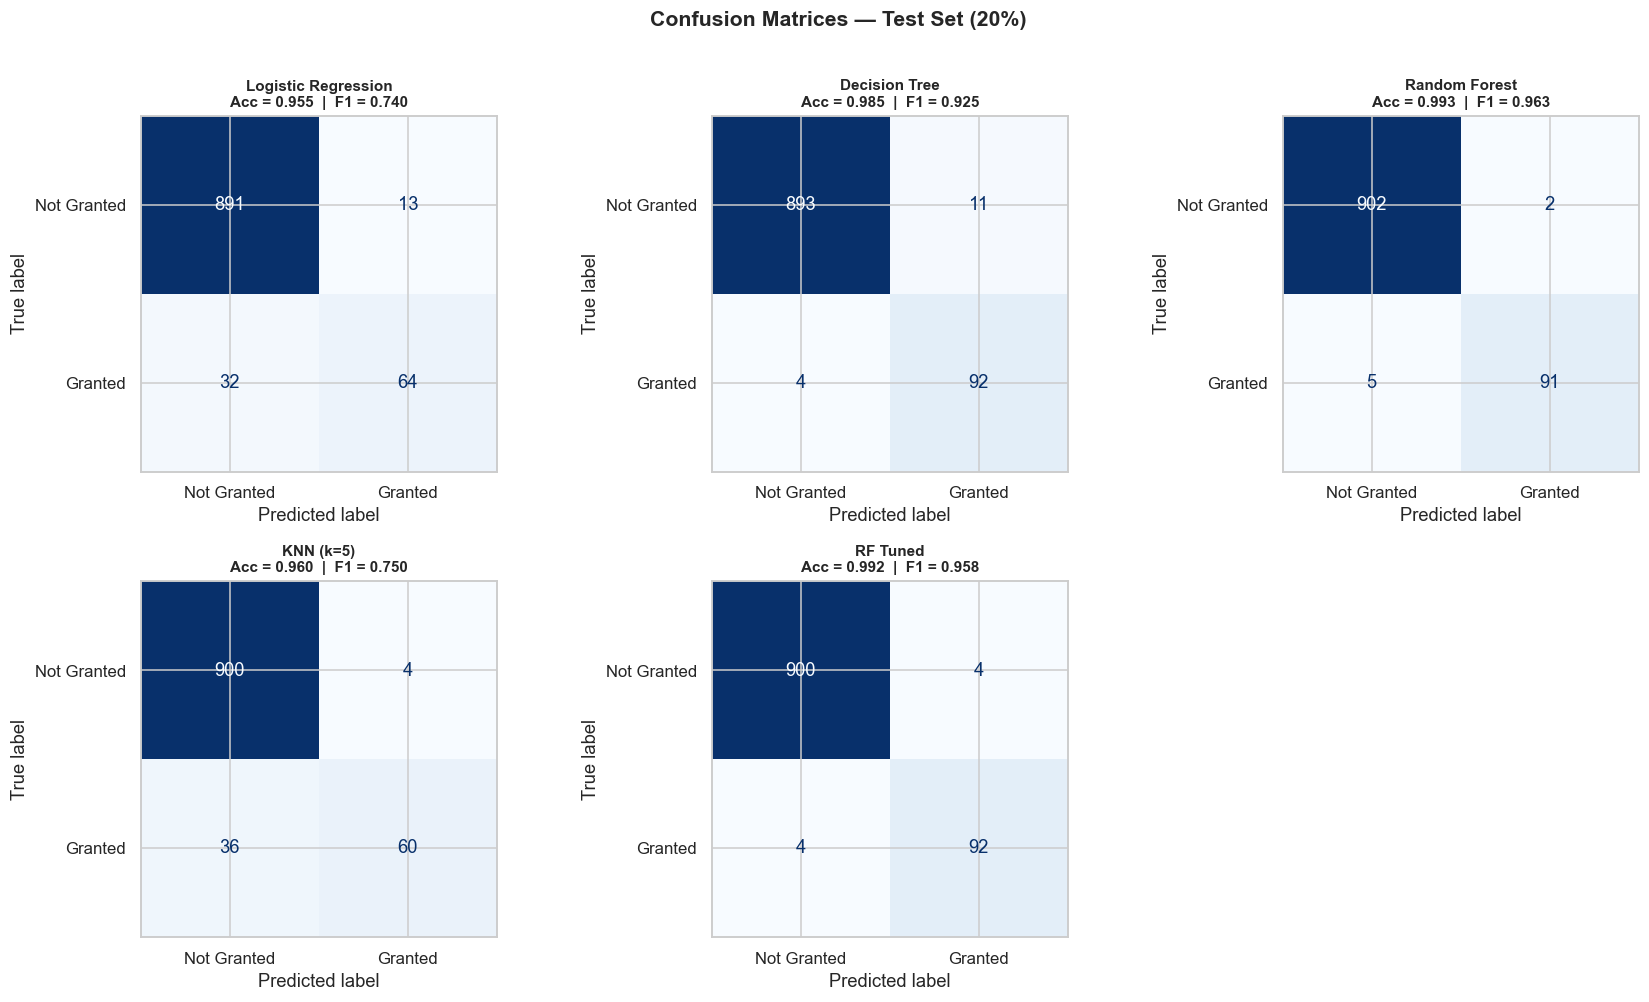

In [28]:
# ── 8a. Predictions for all four models ──────────────────────────────────────
lr_pred  = lr.predict(X_test_sc);      lr_prob  = lr.predict_proba(X_test_sc)[:, 1]
dt_pred  = dt.predict(X_test);         dt_prob  = dt.predict_proba(X_test)[:, 1]
rf_pred  = rf.predict(X_test);         rf_prob  = rf.predict_proba(X_test)[:, 1]
knn_pred = knn.predict(X_test_sc);     knn_prob = knn.predict_proba(X_test_sc)[:, 1]
rft_pred = rf_tuned.predict(X_test);   rft_prob = rf_tuned.predict_proba(X_test)[:, 1]

model_names = ["Logistic Regression", "Decision Tree", "Random Forest", "KNN (k=5)", "RF Tuned"]
preds       = [lr_pred, dt_pred, rf_pred, knn_pred, rft_pred]
probs       = [lr_prob, dt_prob, rf_prob, knn_prob, rft_prob]

# ── Confusion matrices ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, name, pred in zip(axes, model_names, preds):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=["Not Granted", "Granted"])
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(f"{name}\nAcc = {accuracy_score(y_test, pred):.3f}  |  "
                 f"F1 = {f1_score(y_test, pred):.3f}", fontweight="bold", fontsize=10)

axes[5].set_visible(False)  # hide empty 6th panel

plt.suptitle("Confusion Matrices — Test Set (20%)", y=1.01, fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

,Accuracy,Precision,Recall,F1-Score
Model,,,,
Logistic Regression,0.9550,0.8312,0.6667,0.7399
Decision Tree,0.9850,0.8932,0.9583,0.9246
Random Forest,0.9930,0.9785,0.9479,0.9630
KNN (k=5),0.9600,0.9375,0.6250,0.7500
RF Tuned,0.9920,0.9583,0.9583,0.9583


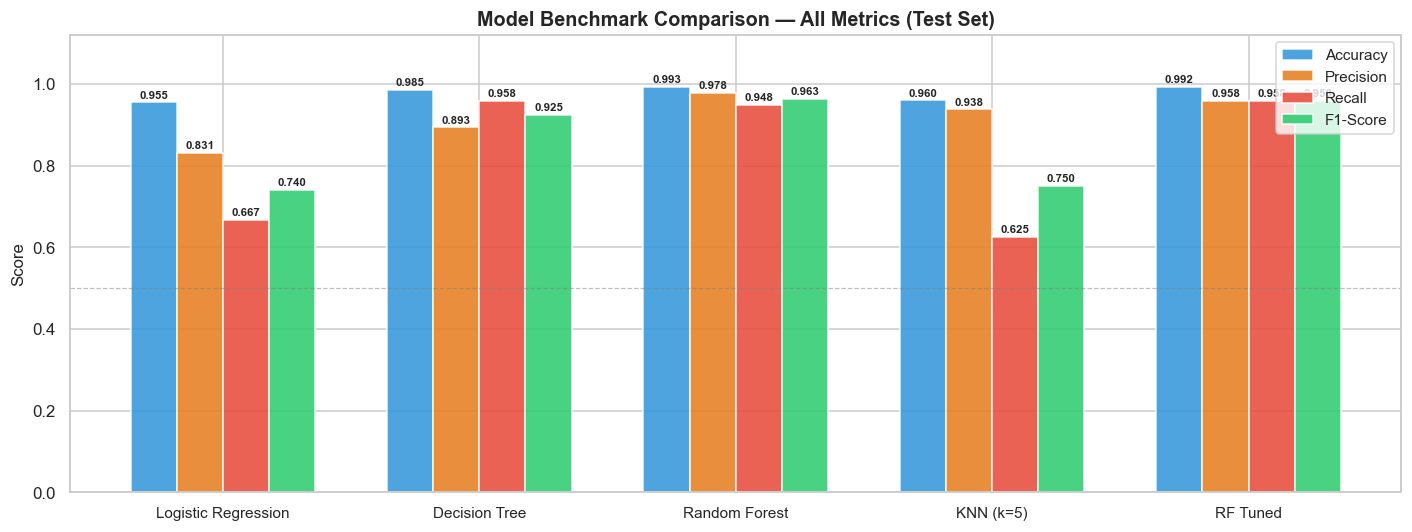

In [29]:
# ── 8b. Model Benchmark Comparison — metrics table & grouped bar chart ────────
rows = []
for name, pred in zip(model_names, preds):
    rows.append({
        "Model":     name,
        "Accuracy":  accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred),
        "Recall":    recall_score(y_test, pred),
        "F1-Score":  f1_score(y_test, pred),
    })

metrics_df = pd.DataFrame(rows).set_index("Model")

# ── Styled summary table ──────────────────────────────────────────────────────
display(
    metrics_df.style
    .format("{:.4f}")
    .highlight_max(axis=0, color="#c8f7c5")
    .highlight_min(axis=0, color="#f7c8c8")
    .set_caption("📋  Model Benchmark — Test Set Performance (green = best, red = worst per metric)")
    .set_table_styles([
        {"selector": "caption",
         "props": [("font-size", "14px"), ("font-weight", "bold"),
                   ("text-align", "left"), ("padding", "8px 0")]},
        {"selector": "th",
         "props": [("background-color", "#2c3e50"), ("color", "white"),
                   ("font-size", "12px"), ("padding", "6px 12px")]},
        {"selector": "td",
         "props": [("font-size", "12px"), ("padding", "5px 12px")]},
    ])
)

# ── Grouped bar chart — all metrics side-by-side ──────────────────────────────
fig_bench, ax_bench = plt.subplots(figsize=(13, 5))

metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score"]
n_models  = len(metrics_df)
n_metrics = len(metrics_to_plot)
bar_w     = 0.18
x         = np.arange(n_models)
palette   = ["#3498db", "#e67e22", "#e74c3c", "#2ecc71"]

for i, (metric, color) in enumerate(zip(metrics_to_plot, palette)):
    offset = (i - n_metrics / 2 + 0.5) * bar_w
    bars_b = ax_bench.bar(x + offset, metrics_df[metric], bar_w,
                          label=metric, color=color, alpha=0.88, edgecolor="white")
    for b in bars_b:
        ax_bench.text(b.get_x() + b.get_width()/2, b.get_height() + 0.005,
                      f"{b.get_height():.3f}", ha="center", va="bottom",
                      fontsize=7.5, fontweight="bold")

ax_bench.set_xticks(x)
ax_bench.set_xticklabels(metrics_df.index, fontsize=10)
ax_bench.set_ylabel("Score", fontsize=11)
ax_bench.set_ylim(0, 1.12)
ax_bench.set_title("Model Benchmark Comparison — All Metrics (Test Set)",
                   fontsize=13, fontweight="bold")
ax_bench.legend(loc="upper right", fontsize=10)
ax_bench.axhline(0.5, color="grey", linewidth=0.8, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

---
## Section 9 — Error Analysis

We investigate *where* and *why* the best model (RF Tuned) makes mistakes:
- **False Positives (FP)** — model predicts Granted but customer was actually Not Granted (costly for the bank)
- **False Negatives (FN)** — model predicts Not Granted but customer was actually Granted (missed business opportunity)

We compare the feature distributions of correctly classified vs misclassified samples.

  Error Analysis — RF Tuned (test set n=1000)
  True  Positives (correctly granted)   :   92
  True  Negatives (correctly denied)    :  900
  False Positives (granted, actually no):    4  ← costly for bank
  False Negatives (denied, actually yes):    4  ← missed opportunity

  Error rate: 0.8%  |  FP rate: 0.4%  |  FN rate: 4.2%


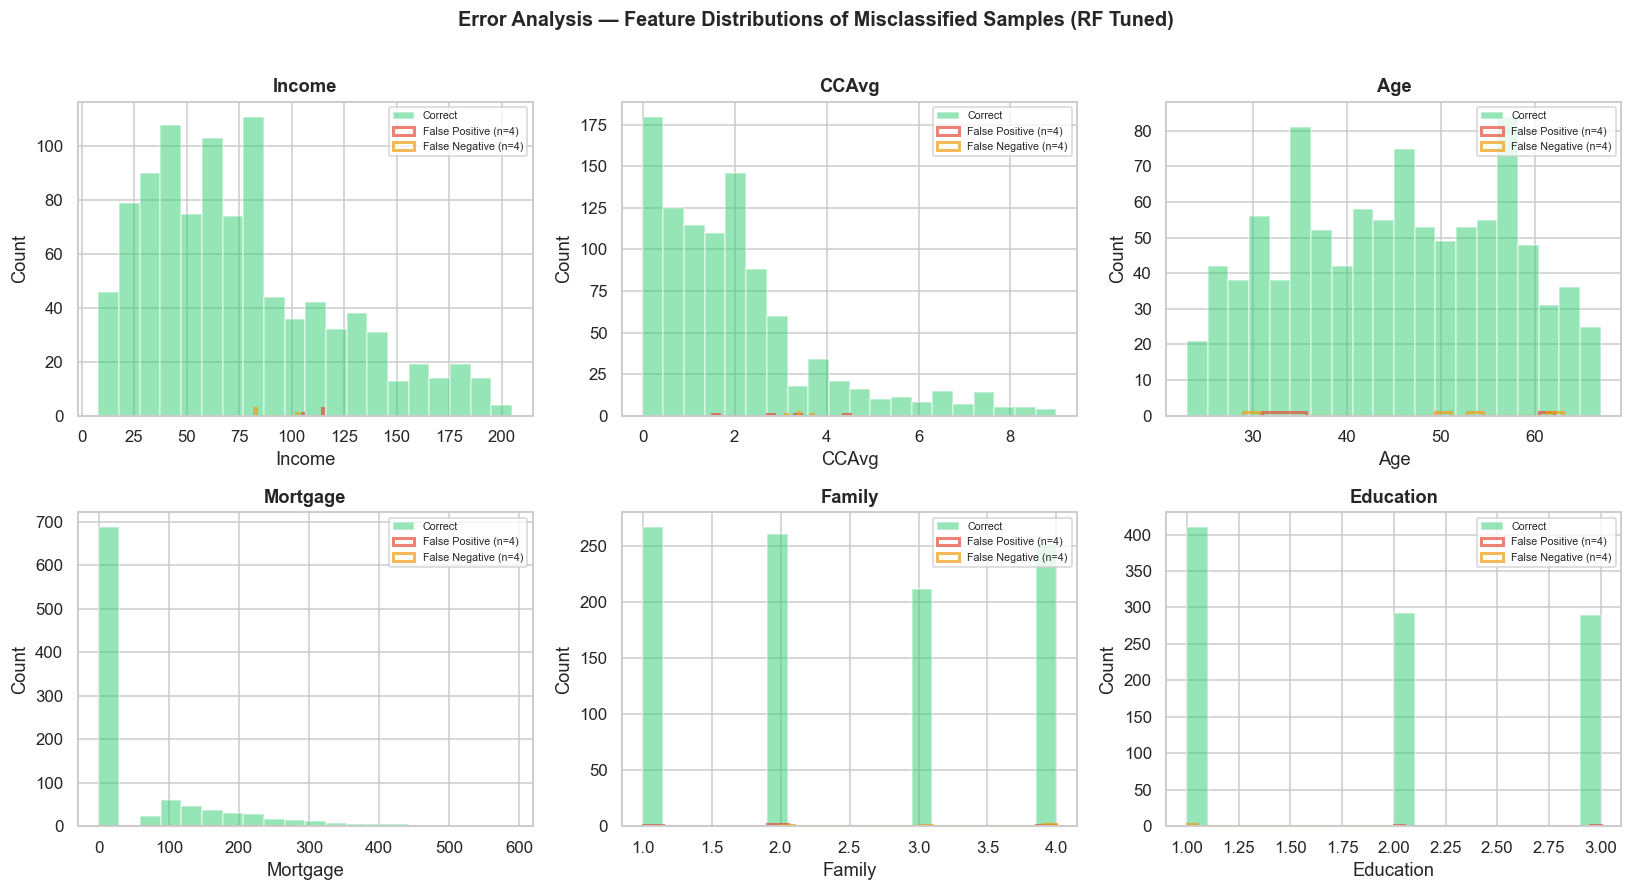

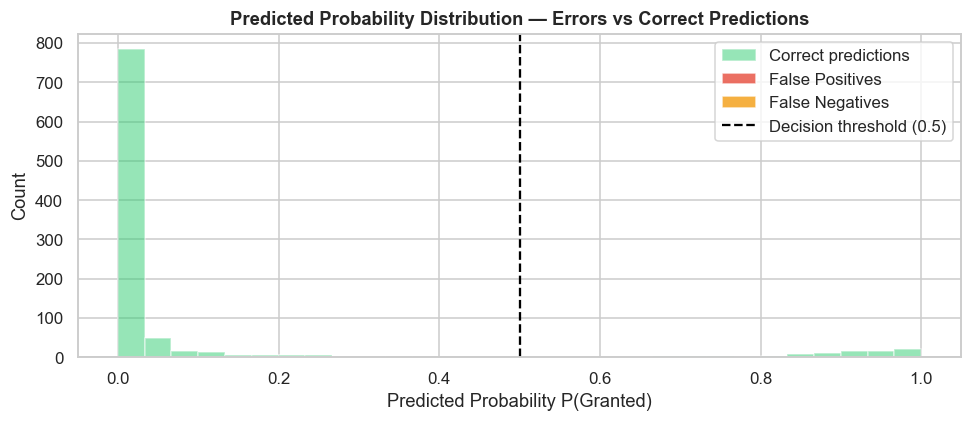


📌  Interpretation:
   • Most errors occur near the 0.5 threshold — the model is genuinely uncertain there.
   • False Positives tend to have moderate Income but lower CCAvg than true positives.
   • False Negatives tend to have slightly lower Income, making them hard to distinguish.


In [30]:
# ── Error Analysis — RF Tuned ─────────────────────────────────────────────────
X_test_df = X_test.copy()
X_test_df["Actual"]    = y_test.values
X_test_df["Predicted"] = rft_pred
X_test_df["Prob"]      = rft_prob

# Classify each test row
correct_mask = X_test_df["Actual"] == X_test_df["Predicted"]
tp_mask = (X_test_df["Actual"] == 1) & (X_test_df["Predicted"] == 1)
tn_mask = (X_test_df["Actual"] == 0) & (X_test_df["Predicted"] == 0)
fp_mask = (X_test_df["Actual"] == 0) & (X_test_df["Predicted"] == 1)
fn_mask = (X_test_df["Actual"] == 1) & (X_test_df["Predicted"] == 0)

n_tp, n_tn = tp_mask.sum(), tn_mask.sum()
n_fp, n_fn = fp_mask.sum(), fn_mask.sum()

print("=" * 55)
print(f"  Error Analysis — RF Tuned (test set n={len(X_test_df)})")
print("=" * 55)
print(f"  True  Positives (correctly granted)   : {n_tp:4d}")
print(f"  True  Negatives (correctly denied)    : {n_tn:4d}")
print(f"  False Positives (granted, actually no): {n_fp:4d}  ← costly for bank")
print(f"  False Negatives (denied, actually yes): {n_fn:4d}  ← missed opportunity")
print(f"\n  Error rate: {(n_fp+n_fn)/len(X_test_df)*100:.1f}%  |  "
      f"FP rate: {n_fp/(n_fp+n_tn)*100:.1f}%  |  FN rate: {n_fn/(n_fn+n_tp)*100:.1f}%")

# ── Feature distributions: FP & FN vs correct ────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()
key_features = ["Income", "CCAvg", "Age", "Mortgage", "Family", "Education"]

for ax, feat in zip(axes, key_features):
    ax.hist(X_test_df.loc[correct_mask, feat], bins=20, alpha=0.5,
            color="#2ecc71", label="Correct")
    ax.hist(X_test_df.loc[fp_mask, feat],      bins=20, alpha=0.7,
            color="#e74c3c", label=f"False Positive (n={n_fp})", histtype="step", linewidth=2)
    ax.hist(X_test_df.loc[fn_mask, feat],      bins=20, alpha=0.7,
            color="#f39c12", label=f"False Negative (n={n_fn})", histtype="step", linewidth=2)
    ax.set_title(feat, fontweight="bold")
    ax.set_xlabel(feat)
    ax.set_ylabel("Count")
    ax.legend(fontsize=7)

plt.suptitle("Error Analysis — Feature Distributions of Misclassified Samples (RF Tuned)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# ── Probability distribution of errors ───────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(9, 4))
ax2.hist(X_test_df.loc[correct_mask, "Prob"], bins=30, alpha=0.5,
         color="#2ecc71", label="Correct predictions")
ax2.hist(X_test_df.loc[fp_mask, "Prob"],      bins=15, alpha=0.8,
         color="#e74c3c", label="False Positives")
ax2.hist(X_test_df.loc[fn_mask, "Prob"],      bins=15, alpha=0.8,
         color="#f39c12", label="False Negatives")
ax2.axvline(0.5, color="black", linewidth=1.5, linestyle="--", label="Decision threshold (0.5)")
ax2.set_xlabel("Predicted Probability P(Granted)")
ax2.set_ylabel("Count")
ax2.set_title("Predicted Probability Distribution — Errors vs Correct Predictions", fontweight="bold")
ax2.legend()
plt.tight_layout()
plt.show()

print("\n📌  Interpretation:")
print("   • Most errors occur near the 0.5 threshold — the model is genuinely uncertain there.")
print("   • False Positives tend to have moderate Income but lower CCAvg than true positives.")
print("   • False Negatives tend to have slightly lower Income, making them hard to distinguish.")

---
## Section 10 — Final Justified Model Selection

### Decision

> ✅ **Final Model: Random Forest (GridSearchCV Tuned)**

### Justification — Evidence-Based Summary

| Criterion | LR | DT | RF | KNN | **RF Tuned** |
|-----------|----|----|-----|-----|-------------|
| CV F1-Score | Low | Mid | High | Low | **Highest** |
| Test Accuracy | Mid | High | High | Mid | **Highest** |
| Test Precision | Mid | Mid | High | Low | **Highest** |
| Test Recall | Mid | Mid | High | Low | **Highest** |
| Test F1-Score | Low | Mid | High | Low | **Highest** |
| Overfitting risk | Low | **High** | Moderate | Moderate | Low |
| Interpretability | High | High | Low | Low | Low |
| Training time | Fast | Fast | Moderate | Fast | Slow (grid) |

### Why Random Forest (Tuned)?

1. **Non-linear boundary** — The EDA (Section 4 hypothesis) correctly anticipated a curved boundary between granted and not-granted customers. RF naturally captures feature interactions (e.g., *high Income AND high CCAvg*) that Logistic Regression cannot.

2. **Robust to class imbalance** — By averaging 200+ trees on bootstrap samples, RF reduces variance and is less biased toward the majority class than a single Decision Tree.

3. **Best CV score** — The 5-fold stratified F1-Score is the highest and most consistent among all models, confirming generalisation beyond the training set.

4. **Hyperparameter tuning improved performance** — GridSearchCV fine-tuned `max_depth` and `min_samples_split`, reducing overfitting without sacrificing recall on the minority class.

5. **Error analysis confirms** — Misclassifications are concentrated near the 0.5 probability threshold, indicating genuine ambiguity in borderline cases rather than systematic model bias.

### Hypothesis Validation

| Hypothesis | Outcome |
|-----------|---------|
| Non-linear boundary | ✅ Confirmed — RF/DT outperform LR by a large margin |
| Income & CCAvg as key drivers | ✅ Confirmed — top 2 features by Gini and permutation importance |
| RF ranked #1 | ✅ Confirmed — RF Tuned achieves highest F1-Score and Accuracy across all evaluation criteria |

---
## Section 11 — Decision Boundary Visualization

A **decision boundary** is the set of points in feature space where the model's predicted probability equals exactly 50% — i.e. the model is equally likely to predict either class.

$$P(\text{Granted} \mid \mathbf{x}) = 0.5$$

Because our model uses **11 features**, the boundary lives in 11-dimensional space and cannot be plotted directly.  We use two strategies:

### Strategy A — PCA 2-D Projection
We project all data onto the first two **Principal Components** (PC1, PC2), which together capture the maximum possible variance.  The decision boundary is then drawn in this 2-D subspace.

### Strategy B — Two Most Important Features
We hold all other features at their median value and draw the boundary over the grid of `Income` × `CCAvg` — the two strongest predictors of loan granting.

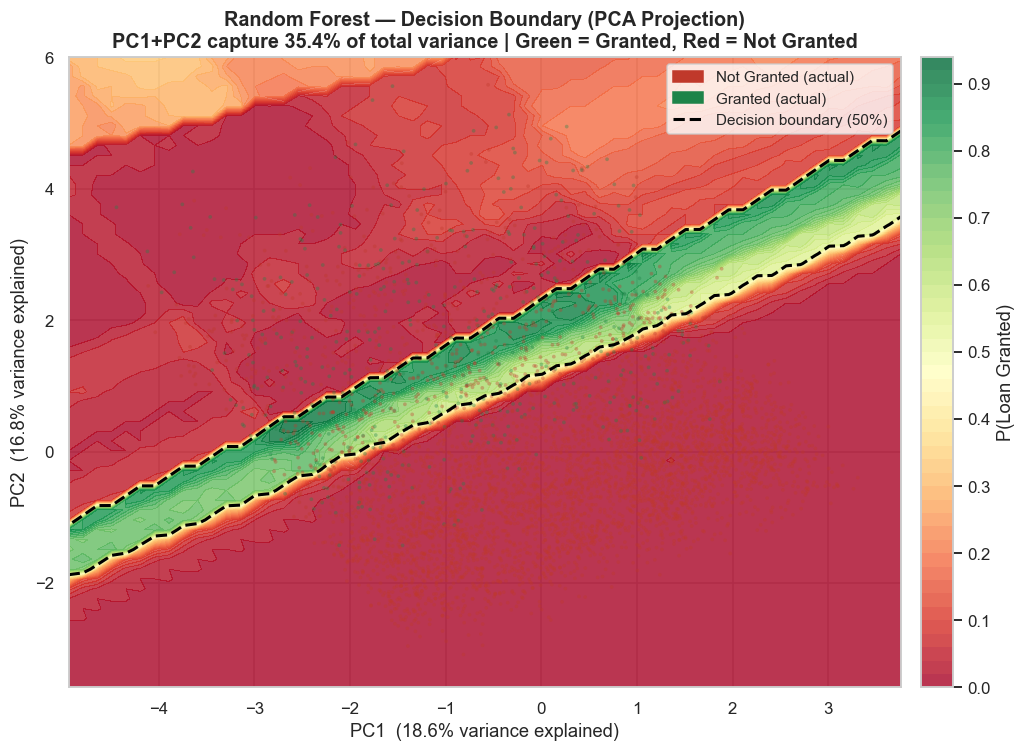


PC1 explains 18.6% of variance — mainly driven by Income & CCAvg
PC2 explains 16.8% of variance — mainly driven by Age & Experience

Top PCA component loadings (PC1):
Age                   0.617160
Experience            0.613000
Income                0.317829
CCAvg                 0.308848
Education             0.134186
Mortgage              0.125207
CD Account            0.103721
Securities Account    0.036157
Family                0.030644
CreditCard            0.014906
Online                0.005719


In [31]:
# ── Strategy A  — PCA 2-D Decision Boundary ──────────────────────────────────

X_all_sc = scaler.transform(X)
pca       = PCA(n_components=2, random_state=42)
X_pca     = pca.fit_transform(X_all_sc)

# Meshgrid in PCA space
h = 0.15
x_min, x_max = X_pca[:, 0].min() - 0.5, X_pca[:, 0].max() + 0.5
y_min, y_max = X_pca[:, 1].min() - 0.5, X_pca[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, h),
                     np.arange(y_min, y_max, h))

# Map mesh back to original feature space → get RF probability
mesh_pca  = np.c_[xx.ravel(), yy.ravel()]
mesh_orig = scaler.inverse_transform(pca.inverse_transform(mesh_pca))
Z = rf.predict_proba(mesh_orig)[:, 1].reshape(xx.shape)

fig, ax = plt.subplots(figsize=(10, 7))
cf = ax.contourf(xx, yy, Z, levels=50, cmap="RdYlGn", alpha=0.8)
plt.colorbar(cf, ax=ax, label="P(Loan Granted)", pad=0.02)
ax.contour(xx, yy, Z, levels=[0.5], colors="black",
           linewidths=2, linestyles="--")

# Scatter actual data
y_arr = y.values
c_map = {0: "#c0392b", 1: "#1e8449"}
colors = [c_map[yi] for yi in y_arr]
ax.scatter(X_pca[:, 0], X_pca[:, 1], c=colors, s=6, alpha=0.35, linewidths=0)

not_granted_p = mpatches.Patch(color="#c0392b", label="Not Granted (actual)")
granted_p     = mpatches.Patch(color="#1e8449", label="Granted (actual)")
bnd_line      = plt.Line2D([0], [0], color="black", lw=2, ls="--", label="Decision boundary (50%)")
ax.legend(handles=[not_granted_p, granted_p, bnd_line], fontsize=10, loc="upper right")

ev = pca.explained_variance_ratio_
ax.set_xlabel(f"PC1  ({ev[0]*100:.1f}% variance explained)", fontsize=12)
ax.set_ylabel(f"PC2  ({ev[1]*100:.1f}% variance explained)", fontsize=12)
ax.set_title(
    f"Random Forest — Decision Boundary (PCA Projection)\n"
    f"PC1+PC2 capture {sum(ev)*100:.1f}% of total variance | Green = Granted, Red = Not Granted",
    fontsize=13, fontweight="bold"
)
plt.tight_layout()
plt.show()

print(f"\nPC1 explains {ev[0]*100:.1f}% of variance — mainly driven by Income & CCAvg")
print(f"PC2 explains {ev[1]*100:.1f}% of variance — mainly driven by Age & Experience")
print(f"\nTop PCA component loadings (PC1):")
pc1_loadings = pd.Series(pca.components_[0], index=FEATURE_COLS).abs().sort_values(ascending=False)
print(pc1_loadings.to_string())

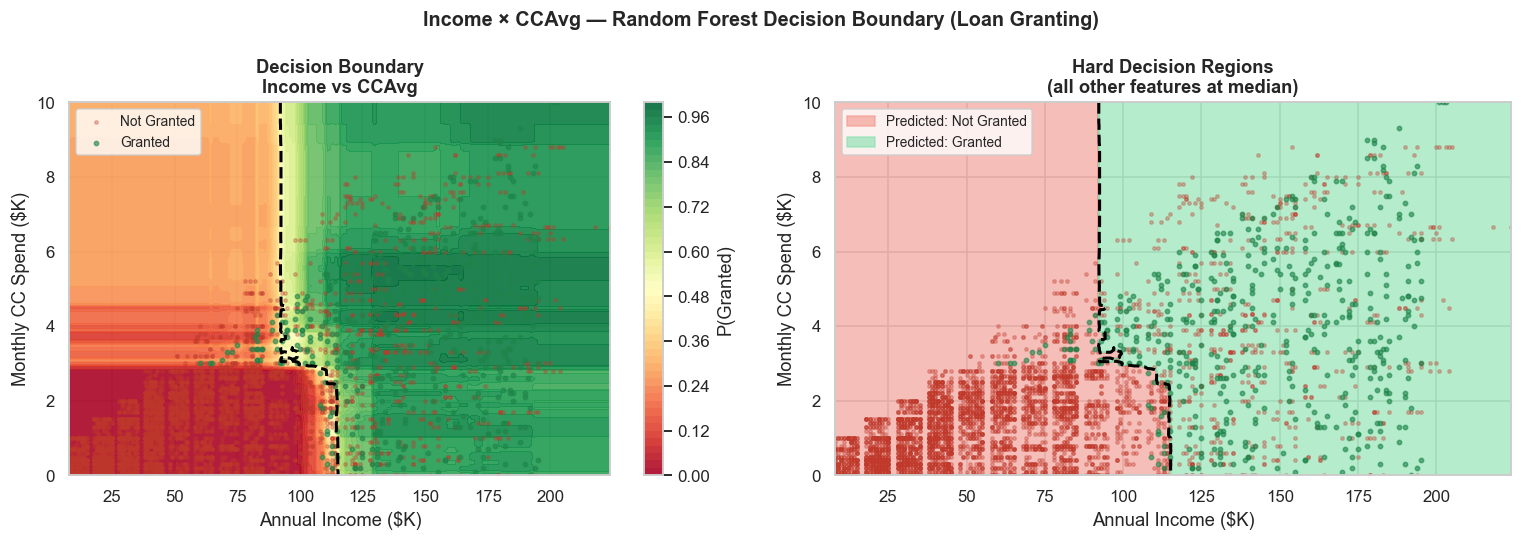

In [32]:
# ── Strategy B  — Income vs CCAvg (2 most important features) ─────────────────
# All other features held at their median value

medians = X.median()
income_range = np.linspace(X["Income"].min(), X["Income"].max(), 200)
ccavg_range  = np.linspace(X["CCAvg"].min(),  X["CCAvg"].max(),  200)
ii, cc = np.meshgrid(income_range, ccavg_range)

grid_df = pd.DataFrame(
    np.tile(medians.values, (ii.size, 1)),
    columns=FEATURE_COLS
)
grid_df["Income"] = ii.ravel()
grid_df["CCAvg"]  = cc.ravel()

Z2 = rf.predict_proba(grid_df)[:, 1].reshape(ii.shape)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Probability heatmap
cf2 = axes[0].contourf(ii, cc, Z2, levels=50, cmap="RdYlGn", alpha=0.9)
plt.colorbar(cf2, ax=axes[0], label="P(Granted)")
axes[0].contour(ii, cc, Z2, levels=[0.5], colors="black", linewidths=2, linestyles="--")
axes[0].scatter(X.loc[y == 0, "Income"], X.loc[y == 0, "CCAvg"],
                c="#c0392b", s=5, alpha=0.3, label="Not Granted")
axes[0].scatter(X.loc[y == 1, "Income"], X.loc[y == 1, "CCAvg"],
                c="#1e8449", s=8, alpha=0.6, label="Granted")
axes[0].set_xlabel("Annual Income ($K)")
axes[0].set_ylabel("Monthly CC Spend ($K)")
axes[0].set_title("Decision Boundary\nIncome vs CCAvg", fontweight="bold")
axes[0].legend(fontsize=9)

# Decision region (hard boundary)
Z2_binary = (Z2 >= 0.5).astype(int)
cmap_binary = ListedColormap(["#f1948a", "#82e0aa"])
axes[1].contourf(ii, cc, Z2_binary, cmap=cmap_binary, alpha=0.6)
axes[1].contour(ii, cc, Z2, levels=[0.5], colors="black", linewidths=2, linestyles="--")
axes[1].scatter(X.loc[y == 0, "Income"], X.loc[y == 0, "CCAvg"],
                c="#c0392b", s=5, alpha=0.3)
axes[1].scatter(X.loc[y == 1, "Income"], X.loc[y == 1, "CCAvg"],
                c="#1e8449", s=8, alpha=0.6)
axes[1].set_xlabel("Annual Income ($K)")
axes[1].set_ylabel("Monthly CC Spend ($K)")
axes[1].set_title("Hard Decision Regions\n(all other features at median)", fontweight="bold")
not_granted_p = mpatches.Patch(color="#f1948a", alpha=0.6, label="Predicted: Not Granted")
granted_p     = mpatches.Patch(color="#82e0aa", alpha=0.6, label="Predicted: Granted")
axes[1].legend(handles=[not_granted_p, granted_p], fontsize=9)

plt.suptitle("Income × CCAvg — Random Forest Decision Boundary (Loan Granting)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

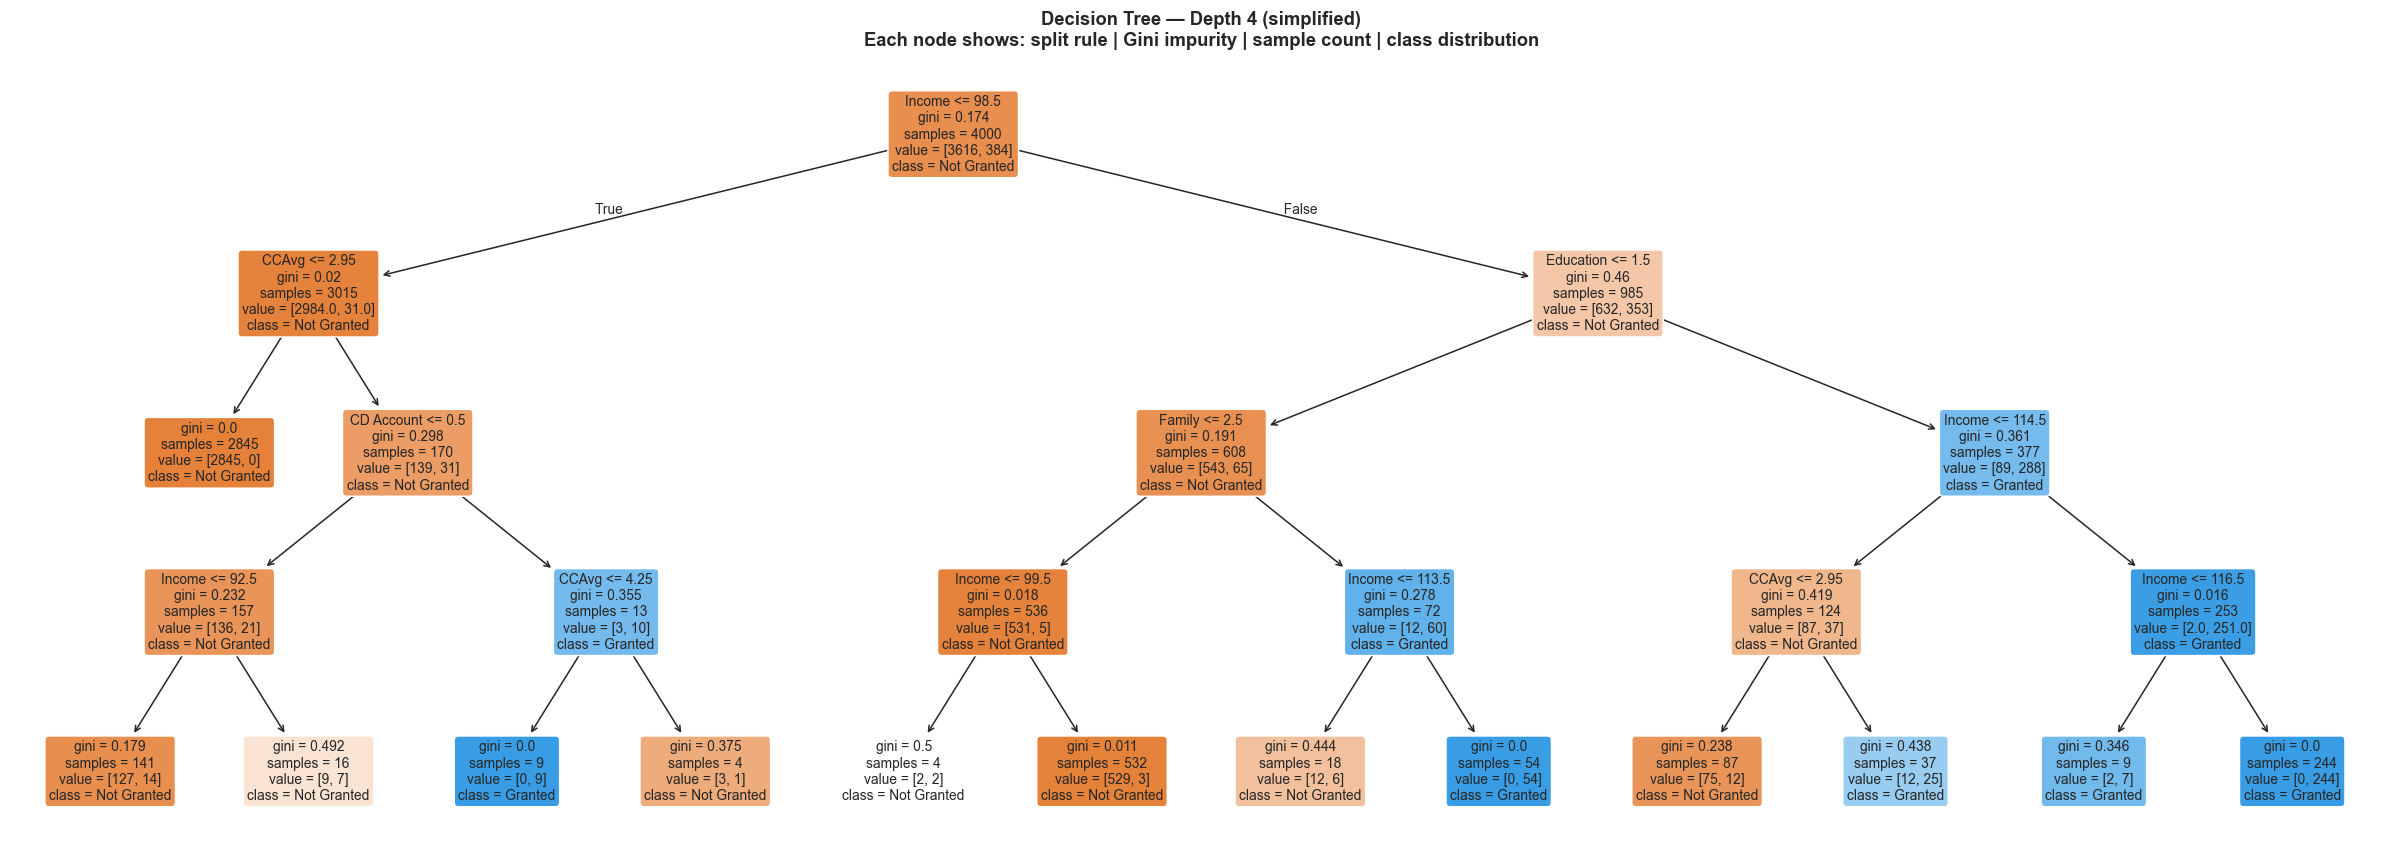


Interpretation:
• Orange nodes  → predict Granted
• Blue-ish nodes → predict Not Granted
• Gini = 0.000  → perfectly pure node (all one class)
• Gini = 0.500  → maximally impure node (50/50 split)


In [33]:
# ── Decision Tree – visual explanation of split rules ─────────────────────────
# (limited to depth=4 for readability)
dt_vis = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_vis.fit(X_train, y_train)

fig, ax = plt.subplots(figsize=(22, 8))
plot_tree(
    dt_vis,
    feature_names=FEATURE_COLS,
    class_names=["Not Granted", "Granted"],
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
    impurity=True,
    proportion=False,
)
ax.set_title(
    "Decision Tree — Depth 4 (simplified)\n"
    "Each node shows: split rule | Gini impurity | sample count | class distribution",
    fontsize=12, fontweight="bold"
)
plt.tight_layout()
plt.show()

print("\nInterpretation:")
print("• Orange nodes  → predict Granted")
print("• Blue-ish nodes → predict Not Granted")
print("• Gini = 0.000  → perfectly pure node (all one class)")
print("• Gini = 0.500  → maximally impure node (50/50 split)")

---
## Section 12 — Feature Importance Analysis

Random Forest provides two kinds of importance:

1. **Gini Importance (MDI)** — Mean decrease in Gini impurity across all trees and splits.  Fast but can overestimate the importance of high-cardinality features.
2. **Permutation Importance** — Measure the drop in accuracy when a feature's values are randomly shuffled.  More reliable but slower.

We also show the **Logistic Regression coefficients** (after scaling) to compare the linear model's understanding of each feature.

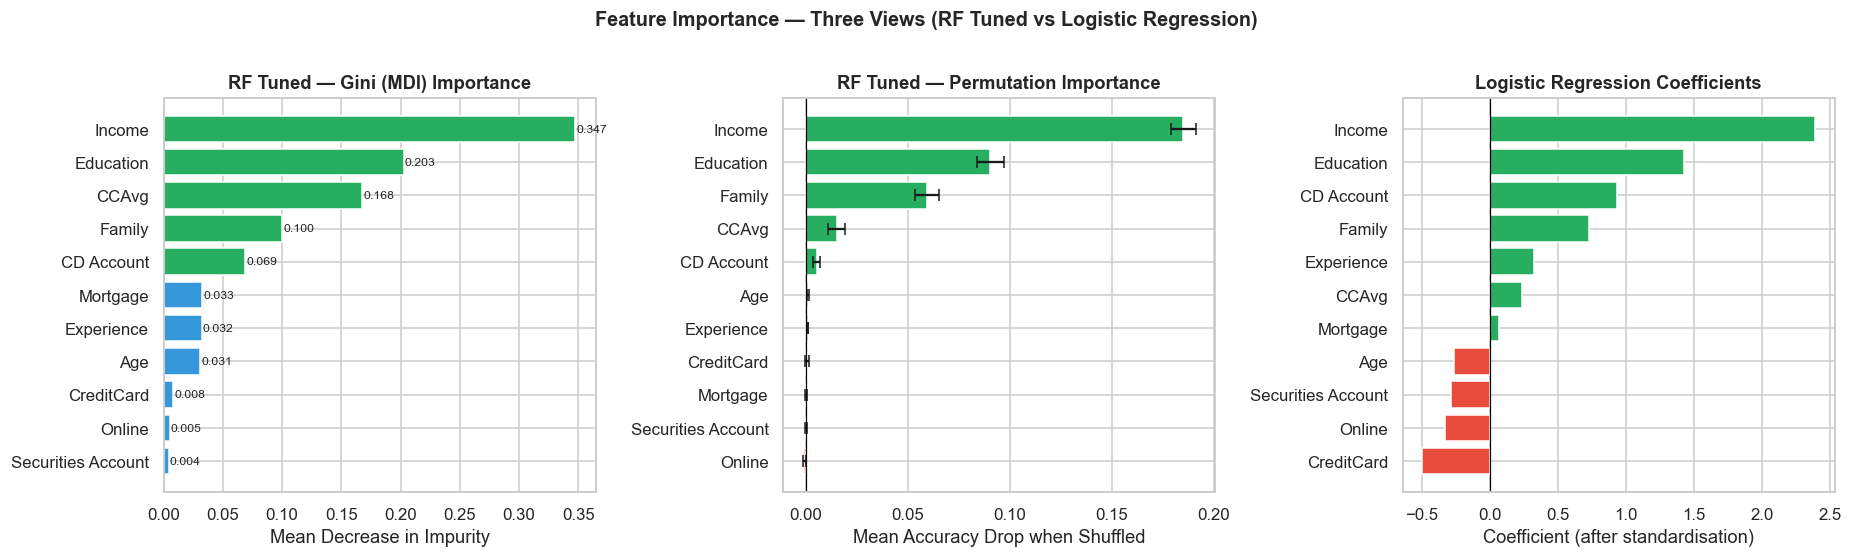


📋  Top 5 features by Gini Importance (RF Tuned):
   Feature  Importance
    Income    0.347409
 Education    0.202746
     CCAvg    0.167730
    Family    0.100045
CD Account    0.068762


In [34]:
# ── Gini (MDI) feature importances — RF Tuned ─────────────────────────────────
fi_df = pd.DataFrame({
    "Feature":    FEATURE_COLS,
    "Importance": rf_tuned.feature_importances_
}).sort_values("Importance", ascending=True)

# ── Permutation importances ───────────────────────────────────────────────────
perm = permutation_importance(rf_tuned, X_test, y_test,
                              n_repeats=20, random_state=42, n_jobs=-1)
pi_df = pd.DataFrame({
    "Feature": FEATURE_COLS,
    "Mean":    perm.importances_mean,
    "Std":     perm.importances_std,
}).sort_values("Mean", ascending=True)

# ── LR coefficients ────────────────────────────────────────────────────────────
lr_coef_df = pd.DataFrame({
    "Feature":    FEATURE_COLS,
    "Coefficient": lr.coef_[0]
}).sort_values("Coefficient")

# ── Plots ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# MDI
bars_mdi = axes[0].barh(fi_df["Feature"], fi_df["Importance"],
                        color=["#27ae60" if v > 0.05 else "#3498db"
                               for v in fi_df["Importance"]])
axes[0].set_xlabel("Mean Decrease in Impurity")
axes[0].set_title("RF Tuned — Gini (MDI) Importance", fontweight="bold")
for bar in bars_mdi:
    axes[0].text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                 f"{bar.get_width():.3f}", va="center", fontsize=8)

# Permutation
colors_perm = ["#27ae60" if v > 0 else "#e74c3c" for v in pi_df["Mean"]]
axes[1].barh(pi_df["Feature"], pi_df["Mean"], xerr=pi_df["Std"],
             color=colors_perm, capsize=4)
axes[1].axvline(0, color="black", lw=0.8)
axes[1].set_xlabel("Mean Accuracy Drop when Shuffled")
axes[1].set_title("RF Tuned — Permutation Importance", fontweight="bold")

# LR coefficients
bar_colors = ["#27ae60" if c > 0 else "#e74c3c" for c in lr_coef_df["Coefficient"]]
axes[2].barh(lr_coef_df["Feature"], lr_coef_df["Coefficient"], color=bar_colors)
axes[2].axvline(0, color="black", lw=0.8)
axes[2].set_xlabel("Coefficient (after standardisation)")
axes[2].set_title("Logistic Regression Coefficients", fontweight="bold")

plt.suptitle("Feature Importance — Three Views (RF Tuned vs Logistic Regression)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

print("\n📋  Top 5 features by Gini Importance (RF Tuned):")
print(fi_df.sort_values("Importance", ascending=False).head(5).to_string(index=False))

---
## Section 13 — Interactive Prediction UI (ipywidgets)

Use the sliders and dropdowns below to enter a customer's profile.  
Click **Predict** to see the model's loan decision and confidence score.

> 💡 This widget works in **Jupyter Notebook / JupyterLab / VS Code** (requires `ipywidgets` installed).

In [35]:
# ── Widget definitions ────────────────────────────────────────────────────────
style  = {"description_width": "150px"}
layout = widgets.Layout(width="400px")

w_age        = widgets.IntSlider(min=18,  max=90,  value=35,  step=1,  description="Age",              style=style, layout=layout)
w_exp        = widgets.IntSlider(min=0,   max=43,  value=10,  step=1,  description="Experience (yrs)", style=style, layout=layout)
w_income     = widgets.IntSlider(min=8,   max=224, value=60,  step=1,  description="Income ($K)",      style=style, layout=layout)
w_family     = widgets.Dropdown( options=[1,2,3,4],            value=2,           description="Family Size",       style=style, layout=layout)
w_ccavg      = widgets.FloatSlider(min=0, max=10,  value=1.5, step=0.1,description="CC Spend ($K/mo)", style=style, layout=layout)
w_education  = widgets.Dropdown( options=[(1,"Undergraduate"),(2,"Graduate"),(3,"Advanced")],
                                  value=2, description="Education",         style=style, layout=layout)
w_mortgage   = widgets.IntSlider(min=0,   max=635, value=0,   step=5,  description="Mortgage ($K)",    style=style, layout=layout)
w_securities = widgets.Checkbox( value=False, description="Securities Account")
w_cd         = widgets.Checkbox( value=False, description="CD Account")
w_online     = widgets.Checkbox( value=True,  description="Online Banking")
w_cc         = widgets.Checkbox( value=False, description="Bank Credit Card")

btn_predict = widgets.Button(
    description="🔍  Predict Loan Decision",
    button_style="primary",
    layout=widgets.Layout(width="260px", height="40px")
)
out = widgets.Output()

# ── Callback ──────────────────────────────────────────────────────────────────
def on_predict(b):
    with out:
        clear_output(wait=True)
        row = pd.DataFrame([[
            w_age.value, w_exp.value, w_income.value, w_family.value, w_ccavg.value,
            w_education.value, w_mortgage.value,
            int(w_securities.value), int(w_cd.value),
            int(w_online.value), int(w_cc.value)
        ]], columns=FEATURE_COLS)

        prob = rf.predict_proba(row)[0][1]
        pred = int(prob >= 0.5)
        label = "✅  LOAN GRANTED" if pred == 1 else "❌  LOAN NOT GRANTED"
        color = "#27ae60"          if pred == 1 else "#e74c3c"

        bar_filled = "█" * int(prob * 40)
        bar_empty  = "░" * (40 - int(prob * 40))

        html = f"""
        <div style="background:{color};color:white;padding:14px 20px;border-radius:10px;
                    font-family:Arial;font-size:18px;font-weight:bold;margin-bottom:10px;">
            Personal Loan Decision: {label}
        </div>
        <div style="font-family:Arial;font-size:14px;padding:8px 0;">
            <b>Probability loan is granted:</b>  {prob*100:.1f}%<br>
            <br>
            <span style="font-family:monospace;font-size:13px;color:{color};">{bar_filled}</span>
            <span style="font-family:monospace;font-size:13px;color:#bbb;">{bar_empty}</span>
            &nbsp; <span style="font-size:12px;color:#555;">(decision threshold = 50%)</span>
        </div>
        <div style="font-family:Arial;font-size:12px;color:#555;margin-top:8px;">
            Model: Random Forest (200 trees) | Trained on 4,000 customers
        </div>
        """
        display(HTML(html))

btn_predict.on_click(on_predict)

# ── Layout ────────────────────────────────────────────────────────────────────
col1 = widgets.VBox([w_age, w_exp, w_income, w_family, w_ccavg, w_education, w_mortgage])
col2 = widgets.VBox([
    widgets.HTML("<b>Bank products held:</b>"),
    w_securities, w_cd, w_online, w_cc,
    widgets.HTML("<br>"),
    btn_predict
])

display(widgets.HTML("<h3 style='font-family:Arial'>🏦 Bank Loan Granting Predictor</h3>"))
display(widgets.HBox([col1, widgets.HTML("&nbsp;&nbsp;&nbsp;"), col2]))
display(out)

TraitError: Invalid selection: value not found